# Data preparation

This notebook contains code to prepare the [PXD014777 dataset](https://proteomecentral.proteomexchange.org/cgi/GetDataset?ID=PXD014777) - Tenzer.nomatching_MaxQuant.txt.zip and HeLa10replicates2h-1.0.10.4_MaxQuant.txt.zip. 

We'll use the following txt files from the zip-files:

HeLa10replicates2h-1.0.10.4_MaxQuant.txt.zip:
- allPeptides.txt: All the peptides with MS-1 data for HeLa
- evidence.txt: A subset of the peptides in allPeptides.txt, which contains both MS-1 and MS-2 data


Tenzer.nomatching_MaxQuant.txt.zip:
- evidence.txt: Contains both MS-1 and MS-2 data for the 3 species: Ecoli, Yeast and HeLa

In [1]:
%matplotlib inline

import os
import pandas as pd

import pipp
import pipp.utils

import re
import numpy as np
import matplotlib.pyplot as plt

/Users/rasmus.larsen/work/peptideprotonet_reproducibility/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Let's define the paths to the raw data.

In [2]:
HELA_MS1_PATH    = "../../data/PXD014777/raw/hela/allPeptides.txt"
HELA_MS2_PATH    = "../../data/PXD014777/raw/hela/evidence.txt"
SPECIES_MS2_PATH = "../../data/PXD014777/raw/species/evidence.txt"

Let's define the paths to the processed output data.

In [3]:
HELA_MS2_MAPPED_PATH    = "../../data/PXD014777/processed/hela_mapped_ms2.csv"

HELA_MS1_OUT_PATH    = "../../data/PXD014777/processed/hela_ms1.csv"
HELA_MS2_OUT_PATH    = "../../data/PXD014777/processed/hela_ms2.csv"
SPECIES_MS2_OUT_PATH = "../../data/PXD014777/processed/species_ms2.csv"

Let's process the data.

In [4]:
df_ms1_hela_raw = pd.read_csv(HELA_MS1_PATH, sep="\t", header=0)

In [5]:
df_ms1_hela_raw["dataset"] = "HeLa"
df_ms1_hela_raw["id"] = np.arange(0, len(df_ms1_hela_raw))

As mentioned in the introduction, the MS2 data is a subset of the MS1 data (with additional features). However, it is not trivial to map the MS2 data back to the MS1 data, due to small differences in feature values. Hence, we can't just compare the features: ['Raw file', 'Charge', 'm/z', 'Mass', 'Intensity', 'Retention time'].
Instead we'll compute a mapping here as we'll later need to know which entries in the MS1 data corresponds to the MS2 data. The indices in MS2 data will match those in MS1 data - after performing the "mapping".

In [6]:
if not os.path.isfile(HELA_MS2_MAPPED_PATH):
    df_ms2_hela_raw = pd.read_csv(HELA_MS2_PATH, sep="\t", header=0, low_memory=False)
    df_ms2_hela_raw = pipp.utils.link_MSMS_to_MS(
        df_ms2_hela_raw, df_ms1_hela_raw, verbose=True
    )
    df_ms2_hela_raw.to_csv(HELA_MS2_MAPPED_PATH, sep="\t", index=True)

In [7]:
df_ms2_hela_raw = pd.read_csv(
    HELA_MS2_PATH, sep="\t", header=0, low_memory=False
)
df_ms2_hela_raw["dataset"] = "HeLa"

In [8]:
df_ms2_species_raw = pd.read_csv(
    SPECIES_MS2_PATH, sep="\t", header=0, low_memory=False
)
df_ms2_species_raw["dataset"] = "multi-species"

Let's look at the dimensions of the data.

In [9]:
print("HeLa MS1 data shape:        {}".format(df_ms1_hela_raw.shape))
print("HeLa MS1+MS2 data shape:    {}".format(df_ms2_hela_raw.shape))
print("species MS1+MS2 data shape: {}".format(df_ms2_species_raw.shape))

HeLa MS1 data shape:        (4101555, 26)
HeLa MS1+MS2 data shape:    (634466, 71)
species MS1+MS2 data shape: (219367, 71)


### MS1 data preprocessing

Let's look at the features available in the MS1 data:

In [10]:
df_ms1_hela_raw.columns.unique()

Index(['Raw file', 'Charge', 'm/z', 'Mass', 'Resolution',
       'Number of data points', 'Number of frames', 'Number of isotopic peaks',
       'Isotope correlation', 'Mass fractional part', 'Mass deficit',
       'Retention time', 'Retention length', 'Retention length (FWHM)',
       'Min frame index', 'Max frame index', 'Ion mobility index',
       'Ion mobility index length', 'Ion mobility index length (FWHM)',
       'Intensity', 'Intensities', 'Number of pasef MS/MS', 'Pasef MS/MS IDs',
       'MS/MS scan number', 'dataset', 'id'],
      dtype='object')

Let's filter out low quality peptides.

In [11]:
df_ms1_hela = df_ms1_hela_raw.loc[
    (df_ms1_hela_raw["Charge"] != 1) & (df_ms1_hela_raw["Intensity"] > 0)
]

In [12]:
ms1_hela_raw_peptides_per_run = [
    np.sum(df_ms1_hela_raw["Raw file"] == run)
    for run in df_ms1_hela_raw["Raw file"].unique()
]
ms1_hela_peptides_per_run = [
    np.sum(df_ms1_hela["Raw file"] == run)
    for run in df_ms1_hela["Raw file"].unique()
]

Text(0, 0.5, 'Number of peptides')

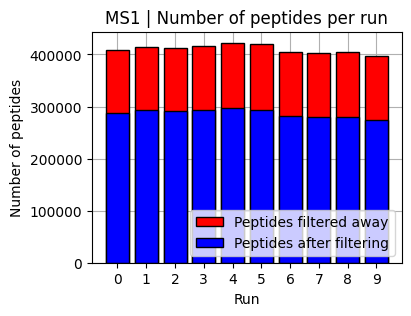

In [13]:
fig, ax = plt.subplots(figsize=(4, 3))

ax.bar(
    range(len(ms1_hela_raw_peptides_per_run)),
    ms1_hela_raw_peptides_per_run,
    color="red",
    edgecolor="black",
)
ax.bar(
    range(len(ms1_hela_peptides_per_run)),
    ms1_hela_peptides_per_run,
    color="blue",
    edgecolor="black",
)
ax.legend(["Peptides filtered away", "Peptides after filtering"], loc="lower right")

ax.grid(True)
ax.set_axisbelow(True)
ax.set_xticks(np.arange(0, len(ms1_hela_raw_peptides_per_run), 1))
ax.set_title("MS1 | Number of peptides per run")
ax.set_xlabel("Run")
ax.set_ylabel("Number of peptides")

In [14]:
f"After filtering | MS1 data points: {df_ms1_hela.shape[0]} ({df_ms1_hela.shape[0] / df_ms1_hela_raw.shape[0] * 100:.2f}%)"

'After filtering | MS1 data points: 2871496 (70.01%)'

It seems like the two types of datasets (MS1 and MS2) use a different name for 'Ion mobilility index length' / 'Ion mobility length'. Let's rename one of them to be consistent between the datasets.

In [15]:
df_ms1_hela = df_ms1_hela.copy()
df_ms1_hela.rename(
    columns={"Ion mobility index length": "Ion mobility length"}, inplace=True
)

### MS2 (MSMS) data preprocessing

#### HeLa - MS2 data

Let's filter out low quality peptides.

In [16]:
# filter out low quality peptides
df_ms2_hela = df_ms2_hela_raw.loc[
    (df_ms2_hela_raw["Charge"] != 1) & (df_ms2_hela_raw["Intensity"] > 0)
]

# keep the most intense peptides
df_ms2_hela = df_ms2_hela.loc[
    df_ms2_hela.groupby(["Modified sequence", "Charge", "Raw file"])[
        "Intensity"
    ].idxmax()
]

# remove contaminants
df_ms2_hela = df_ms2_hela.loc[
    [
        (not bool(re.search("CON__|REV__", i)))
        for i in df_ms2_hela["Leading razor protein"].tolist()
    ]
]

# define identifier for each peptide
df_ms2_hela["PrecursorID"] = (
    df_ms2_hela["Modified sequence"]
    .astype(str)
    .str.cat(df_ms2_hela["Charge"].astype(str), sep="")
)

In [17]:
ms2_hela_raw_peptides_per_run = [
    np.sum(df_ms2_hela_raw["Raw file"] == run)
    for run in df_ms2_hela_raw["Raw file"].unique()
]
ms2_hela_peptides_per_run = [
    np.sum(df_ms2_hela["Raw file"] == run)
    for run in df_ms2_hela["Raw file"].unique()
]

Text(0, 0.5, 'Number of peptides')

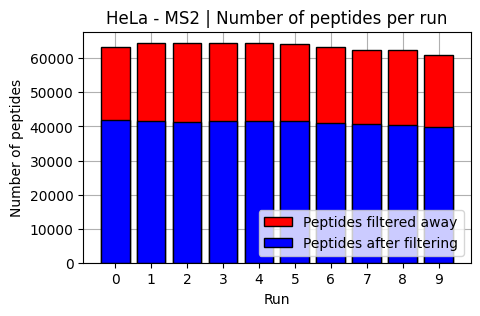

In [18]:
fig, ax = plt.subplots(figsize=(5, 3))

ax.bar(
    range(len(ms2_hela_raw_peptides_per_run)),
    ms2_hela_raw_peptides_per_run,
    color="red",
    edgecolor="black",
)
ax.bar(
    range(len(ms2_hela_peptides_per_run)),
    ms2_hela_peptides_per_run,
    color="blue",
    edgecolor="black",
)
ax.legend(["Peptides filtered away", "Peptides after filtering"], loc="lower right")

ax.grid(True)
ax.set_axisbelow(True)
ax.set_title("HeLa - MS2 | Number of peptides per run")
ax.set_xticks(np.arange(0, len(ms2_hela_raw_peptides_per_run), 1))
ax.set_xlabel("Run")
ax.set_ylabel("Number of peptides")

In [19]:
f"After filtering | MS2 data points: {df_ms2_hela.shape[0]} ({df_ms2_hela.shape[0] / df_ms2_hela_raw.shape[0] * 100:.2f}%)"

'After filtering | MS2 data points: 411838 (64.91%)'

Let's add a column with species.

In [20]:
df_ms2_hela["Species"] = "HeLa"

#### Ecoli, Yeast and HeLa - MS2 data

Let's filter out low quality peptides.

In [21]:
# filter out low quality peptides
df_ms2_species = df_ms2_species_raw.loc[
    (df_ms2_species_raw["Charge"] != 1) & (df_ms2_species_raw["Intensity"] > 0)
]

# keep the most intense peptides
df_ms2_species = df_ms2_species.loc[
    df_ms2_species.groupby(["Modified sequence", "Charge", "Raw file"])[
        "Intensity"
    ].idxmax()
]

# remove contaminants
df_ms2_species = df_ms2_species.loc[
    [
        (not bool(re.search("CON__|REV__", i)))
        for i in df_ms2_species["Leading razor protein"].tolist()
    ]
]

# define identifier for each peptide
df_ms2_species["PrecursorID"] = (
    df_ms2_species["Modified sequence"]
    .astype(str)
    .str.cat(df_ms2_species["Charge"].astype(str), sep="")
)

In [22]:
ms2_species_raw_peptides_per_run = [
    np.sum(df_ms2_species_raw["Raw file"] == run)
    for run in df_ms2_species_raw["Raw file"].unique()
]
ms2_species_peptides_per_run = [
    np.sum(df_ms2_species["Raw file"] == run)
    for run in df_ms2_species["Raw file"].unique()
]

Text(0, 0.5, 'Number of peptides')

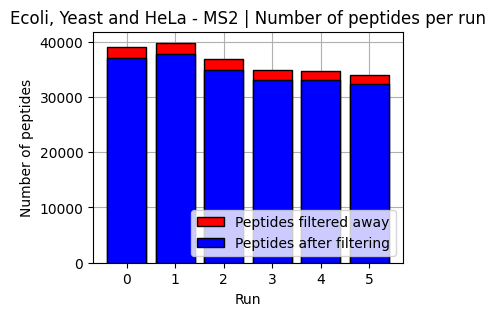

In [23]:
fig, ax = plt.subplots(figsize=(4, 3))

ax.bar(
    range(len(ms2_species_raw_peptides_per_run)),
    ms2_species_raw_peptides_per_run,
    color="red",
    edgecolor="black",
)
ax.bar(
    range(len(ms2_species_peptides_per_run)),
    ms2_species_peptides_per_run,
    color="blue",
    edgecolor="black",
)
ax.legend(["Peptides filtered away", "Peptides after filtering"], loc="lower right")

ax.grid(True)
ax.set_axisbelow(True)
ax.set_title("Ecoli, Yeast and HeLa - MS2 | Number of peptides per run")
ax.set_xlabel("Run")
ax.set_ylabel("Number of peptides")

In [24]:
f"After filtering | MS2 data points: {df_ms2_species.shape[0]} ({df_ms2_species.shape[0] / df_ms2_species_raw.shape[0] * 100:.2f}%)"

'After filtering | MS2 data points: 208091 (94.86%)'

Let's add a column with species.

In [25]:
yeast_filter = df_ms2_species['Leading razor protein'].str.contains('YEAST')
ecoli_filter = df_ms2_species['Leading razor protein'].str.contains('ECOLI')
hela_filter = ~(yeast_filter | ecoli_filter)

df_ms2_species['Species'] = 'Unknown'
df_ms2_species.loc[yeast_filter, 'Species'] = 'Yeast'
df_ms2_species.loc[ecoli_filter, 'Species'] = 'Ecoli'
df_ms2_species.loc[hela_filter, 'Species'] = 'HeLa'

Let's look at the proportion of peptides in each species for the MS2 dataset with multiple species.

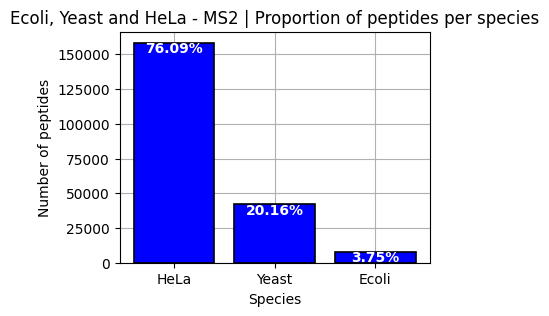

In [26]:
species = df_ms2_species['Species']

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(species.value_counts().index, species.value_counts(), color='blue', edgecolor='black', linewidth=1.2)
ax.set_title('Ecoli, Yeast and HeLa - MS2 | Proportion of peptides per species')
ax.set_xlabel('Species')
ax.set_ylabel('Number of peptides')
ax.grid(True)
ax.set_axisbelow(True)

for i, v in enumerate(species.value_counts()):
    y = v - 4000
    text = f"{v / df_ms2_species.shape[0] * 100:.2f}%"
    ax.text(i, y, text, ha='center', va='center', fontweight='bold', color='white')

Save processed data.

In [27]:
df_ms1_hela.to_csv(HELA_MS1_OUT_PATH, index=False)
df_ms2_hela.to_csv(HELA_MS2_OUT_PATH, index=False)
df_ms2_species.to_csv(SPECIES_MS2_OUT_PATH, index=False)

In [28]:
df_ms1_hela.head()

,Raw file,Charge,m/z,Mass,Resolution,Number of data points,Number of frames,Number of isotopic peaks,Isotope correlation,Mass fractional part,...,Ion mobility index,Ion mobility length,Ion mobility index length (FWHM),Intensity,Intensities,Number of pasef MS/MS,Pasef MS/MS IDs,MS/MS scan number,dataset,id
18,20190122_HeLa_QC_Slot1-47_1_3219,3,338.52001,1012.5382,20884.156611,16778,45,2,0.986931,0.538192,...,633,54,27,47222.0,NaN,0,NaN,NaN,HeLa,18
44,20190122_HeLa_QC_Slot1-47_1_3219,3,376.48995,1126.4480,22896.168980,1113,7,2,0.654756,0.448008,...,615,102,54,50436.0,NaN,0,NaN,NaN,HeLa,44
291,20190122_HeLa_QC_Slot1-47_1_3219,3,373.48579,1117.4356,19579.931100,303,7,2,0.674029,0.435551,...,693,15,15,4560.5,NaN,0,NaN,NaN,HeLa,291
421,20190122_HeLa_QC_Slot1-47_1_3219,4,375.26205,1497.0191,10871.346645,111,5,2,0.885342,0.019077,...,708,9,9,3441.5,NaN,0,NaN,NaN,HeLa,421
460,20190122_HeLa_QC_Slot1-47_1_3219,3,375.46615,1123.3766,18534.680312,380,9,2,0.654371,0.376608,...,711,18,15,5453.3,NaN,0,NaN,NaN,HeLa,460


In [29]:
df_ms1_hela.columns

Index(['Raw file', 'Charge', 'm/z', 'Mass', 'Resolution',
       'Number of data points', 'Number of frames', 'Number of isotopic peaks',
       'Isotope correlation', 'Mass fractional part', 'Mass deficit',
       'Retention time', 'Retention length', 'Retention length (FWHM)',
       'Min frame index', 'Max frame index', 'Ion mobility index',
       'Ion mobility length', 'Ion mobility index length (FWHM)', 'Intensity',
       'Intensities', 'Number of pasef MS/MS', 'Pasef MS/MS IDs',
       'MS/MS scan number', 'dataset', 'id'],
      dtype='object')

In [30]:
df_ms2_hela.head()

,Sequence,Length,Modifications,Modified sequence,Oxidation (M) Probabilities,Oxidation (M) Score Diffs,Acetyl (Protein N-term),Oxidation (M),Missed cleavages,Proteins,...,Protein group IDs,Peptide ID,Mod. peptide ID,MS/MS IDs,Best MS/MS,AIF MS/MS IDs,Oxidation (M) site IDs,dataset,PrecursorID,Species
20,AAAAAAAAAAGAAGGR,16,Acetyl (Protein N-term),_(ac)AAAAAAAAAAGAAGGR_,NaN,NaN,1,0,0,Q86U42,...,3443,2,2,20.0,20.0,NaN,NaN,HeLa,_(ac)AAAAAAAAAAGAAGGR_2,HeLa
21,AAAAAAAAAAGAAGGR,16,Acetyl (Protein N-term),_(ac)AAAAAAAAAAGAAGGR_,NaN,NaN,1,0,0,Q86U42,...,3443,2,2,21.0,21.0,NaN,NaN,HeLa,_(ac)AAAAAAAAAAGAAGGR_2,HeLa
22,AAAAAAAAAAGAAGGR,16,Acetyl (Protein N-term),_(ac)AAAAAAAAAAGAAGGR_,NaN,NaN,1,0,0,Q86U42,...,3443,2,2,22.0,22.0,NaN,NaN,HeLa,_(ac)AAAAAAAAAAGAAGGR_2,HeLa
23,AAAAAAAAAAGAAGGR,16,Acetyl (Protein N-term),_(ac)AAAAAAAAAAGAAGGR_,NaN,NaN,1,0,0,Q86U42,...,3443,2,2,23.0,23.0,NaN,NaN,HeLa,_(ac)AAAAAAAAAAGAAGGR_2,HeLa
24,AAAAAAAAAAGAAGGR,16,Acetyl (Protein N-term),_(ac)AAAAAAAAAAGAAGGR_,NaN,NaN,1,0,0,Q86U42,...,3443,2,2,24.0,24.0,NaN,NaN,HeLa,_(ac)AAAAAAAAAAGAAGGR_2,HeLa


In [31]:
df_ms2_hela.columns

Index(['Sequence', 'Length', 'Modifications', 'Modified sequence',
       'Oxidation (M) Probabilities', 'Oxidation (M) Score Diffs',
       'Acetyl (Protein N-term)', 'Oxidation (M)', 'Missed cleavages',
       'Proteins', 'Leading proteins', 'Leading razor protein', 'Gene names',
       'Protein names', 'Type', 'Raw file', 'Experiment', 'MS/MS m/z',
       'Charge', 'm/z', 'Mass', 'Resolution',
       'Uncalibrated - Calibrated m/z [ppm]',
       'Uncalibrated - Calibrated m/z [Da]', 'Mass error [ppm]',
       'Mass error [Da]', 'Uncalibrated mass error [ppm]',
       'Uncalibrated mass error [Da]', 'Max intensity m/z 0', 'Retention time',
       'Retention length', 'Calibrated retention time',
       'Calibrated retention time start', 'Calibrated retention time finish',
       'Retention time calibration', 'Ion mobility index',
       'Ion mobility length', '1/K0', '1/K0 length', 'Calibrated 1/K0', 'CCS',
       'CCS length', 'Match time difference', 'Match m/z difference',
       '

In [32]:
df_ms2_species.head()

,Sequence,Length,Modifications,Modified sequence,Oxidation (M) Probabilities,Oxidation (M) Score Diffs,Acetyl (Protein N-term),Oxidation (M),Missed cleavages,Proteins,...,Protein group IDs,Peptide ID,Mod. peptide ID,MS/MS IDs,Best MS/MS,AIF MS/MS IDs,Oxidation (M) site IDs,dataset,PrecursorID,Species
1,AAAAAAAAAAGAAGGR,16,Acetyl (Protein N-term),_(ac)AAAAAAAAAAGAAGGR_,NaN,NaN,1,0,0,Q86U42,...,3188,1,1,1,1,NaN,NaN,multi-species,_(ac)AAAAAAAAAAGAAGGR_2,HeLa
2,AAAAAAAAAAGAAGGR,16,Acetyl (Protein N-term),_(ac)AAAAAAAAAAGAAGGR_,NaN,NaN,1,0,0,Q86U42,...,3188,1,1,2,2,NaN,NaN,multi-species,_(ac)AAAAAAAAAAGAAGGR_2,HeLa
3,AAAAAAAAAAGAAGGR,16,Acetyl (Protein N-term),_(ac)AAAAAAAAAAGAAGGR_,NaN,NaN,1,0,0,Q86U42,...,3188,1,1,3,3,NaN,NaN,multi-species,_(ac)AAAAAAAAAAGAAGGR_2,HeLa
4,AAAAAAAAAAGAAGGR,16,Acetyl (Protein N-term),_(ac)AAAAAAAAAAGAAGGR_,NaN,NaN,1,0,0,Q86U42,...,3188,1,1,4,4,NaN,NaN,multi-species,_(ac)AAAAAAAAAAGAAGGR_2,HeLa
5,AAAAAAAAAAGAAGGR,16,Acetyl (Protein N-term),_(ac)AAAAAAAAAAGAAGGR_,NaN,NaN,1,0,0,Q86U42,...,3188,1,1,5,5,NaN,NaN,multi-species,_(ac)AAAAAAAAAAGAAGGR_2,HeLa


In [33]:
df_ms2_species.columns

Index(['Sequence', 'Length', 'Modifications', 'Modified sequence',
       'Oxidation (M) Probabilities', 'Oxidation (M) Score Diffs',
       'Acetyl (Protein N-term)', 'Oxidation (M)', 'Missed cleavages',
       'Proteins', 'Leading proteins', 'Leading razor protein', 'Gene names',
       'Protein names', 'Type', 'Raw file', 'Experiment', 'MS/MS m/z',
       'Charge', 'm/z', 'Mass', 'Resolution',
       'Uncalibrated - Calibrated m/z [ppm]',
       'Uncalibrated - Calibrated m/z [Da]', 'Mass error [ppm]',
       'Mass error [Da]', 'Uncalibrated mass error [ppm]',
       'Uncalibrated mass error [Da]', 'Max intensity m/z 0', 'Retention time',
       'Retention length', 'Calibrated retention time',
       'Calibrated retention time start', 'Calibrated retention time finish',
       'Retention time calibration', 'Ion mobility index',
       'Ion mobility length', '1/K0', '1/K0 length', 'Calibrated 1/K0', 'CCS',
       'CCS length', 'Match time difference', 'Match m/z difference',
       '